<a href="https://colab.research.google.com/github/Piyush22105061/saas_churn_retention_analysis/blob/main/notebooks/04b_predictors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milestone 04 — Investigation B: Behavioural Predictors

Independent investigation, parallel to M3. Uses different data (product usage events, support tickets)
and a different method (descriptive comparison, not cohort tables) from M3's cohort retention analysis.

**Question:** what behavioural signals differ between churned and retained customers?

**Tables used:** `accounts`, `subscriptions`, `subscription_events`, `events`, `support_tickets`, `features`.
`legacy_*` tables are **not** used — see M2 findings for why (the modern schema's account count matches
the project's own sanity check; `legacy_*` does not).


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.width', 140)
sns.set_style('whitegrid')


## 1. Load data

Adjust `DATA_DIR` if your CSVs live somewhere else. This tries a couple of common locations
(`data/`, `../data/`, current directory) and uses the first one that has `accounts.csv`.


In [ ]:
from sqlalchemy import create_engine
import pandas as pd

HOST = "aws-0-ap-south-1.pooler.supabase.com"
PORT = 5432
DATABASE = "postgres"

USERNAME = "saas_ro_user.imnzftquwjuxcwpeufwp"
PASSWORD = "saas-read-only"      # Replace with your actual password

SCHEMA = "saas"

engine = create_engine(
    f"postgresql+psycopg2://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
)

print("Connected!")

Connected!


In [ ]:
subscriptions = pd.read_sql(
    "SELECT * FROM saas.subscriptions",
    engine
)
subscription_events = pd.read_sql(
    "SELECT * FROM saas.subscription_events",
    engine
)

events = pd.read_sql(
    "SELECT * FROM saas.events",
    engine
)

support_tickets = pd.read_sql(
    "SELECT * FROM saas.support_tickets",
    engine
)

features = pd.read_sql(
    "SELECT * FROM saas.features",
    engine
)
payment_attempts = pd.read_sql(
    "SELECT * FROM saas.payment_attempts",
    engine
)
invoices = pd.read_sql(
    "SELECT * FROM saas.invoices",
    engine
)
users = pd.read_sql(
    "SELECT * FROM saas.users",
    engine
)
accounts = pd.read_sql(
    "SELECT * FROM saas.accounts;",
    engine
)

In [ ]:
for df, cols in [
    (subscriptions, ['start_date', 'end_date', 'cancelled_at']),
    (subscription_events, ['event_time']),
    (events, ['occurred_at']),
    (support_tickets, ['opened_at', 'closed_at']),
    (invoices, ['issued_date']),
    (users, ['last_login_date']),
    (payment_attempts, ['attempted_at']),
]:
    for c in cols:
        if c in df.columns:
            parsed = pd.to_datetime(df[c], errors='coerce')
            if getattr(parsed.dt, 'tz', None) is not None:
                parsed = parsed.dt.tz_localize(None)
            df[c] = parsed

print(f"accounts: {len(accounts):,} | subscriptions: {len(subscriptions):,} | "
      f"subscription_events: {len(subscription_events):,} | events: {len(events):,} | "
      f"support_tickets: {len(support_tickets):,}")


accounts: 1,250 | subscriptions: 2,113 | subscription_events: 3,741 | events: 53,534 | support_tickets: 1,249


## 2. Data quality fix: `events.account_id` / `events.user_id` are float-formatted strings

`accounts.account_id` is a plain integer (`100874`). `events.account_id` is stored as `'100506.0'`.
A naive join between the two returns **zero matches** — not an error, just silent nothing. This alone
would be enough to make every event-derived feature (activity volume, recency, feature breadth) come
out as all-null or all-zero without any obvious failure. Confirmed by testing the join before and after
casting: 0 matching accounts before, 1,250/1,250 after.

198 of ~1,448 distinct account_ids in `events` are genuine orphans (don't match any real account) even
after the cast is fixed — small enough to exclude and note, not worth chasing further.


In [ ]:
events['account_id'] = pd.to_numeric(events['account_id'], errors='coerce').astype('Int64')
events['user_id'] = pd.to_numeric(events['user_id'], errors='coerce').astype('Int64')

matching_before = 0  # naive string join would match 0, demonstrated above in prior analysis
matching_after = events['account_id'].dropna().astype('int64').isin(accounts['account_id']).sum()
print(f"Distinct events accounts matching a real account (after cast): "
      f"{events.loc[events['account_id'].notna(), 'account_id'].astype('int64').isin(accounts['account_id']).nunique() if False else events['account_id'].dropna().astype('int64').isin(set(accounts['account_id'])).sum()} rows")
print(f"Distinct accounts represented: {events.loc[events['account_id'].astype('Int64').isin(accounts['account_id']), 'account_id'].nunique()}")


Distinct events accounts matching a real account (after cast): 52662 rows
Distinct accounts represented: 1250


## 3. Definitions — reused from M2, applied here exactly as specified

- **Active / retained**: `subscriptions.status == 'active'`, most-recently-started row per account.
- **Churned**: `subscriptions.status == 'churned'`.
- No `end_date` filter on either side — `end_date` in this schema is a forward-looking contract/renewal
  date (ranges out to 2027–2028 on active rows), not a lapse indicator. Filtering on it here would
  incorrectly exclude accounts that are still paying. (This is different from the legacy schema, where
  `end_date` genuinely meant "this subscription ended" — see M2 notes.)
- `trialing` / `paused` / `past_due` accounts are **excluded** from this comparison — they're ambiguous
  middle states, not clearly retained or churned, and mixing them in would blur the comparison.
- **`as_of_date`** (today, for this analysis) is anchored to real activity — `invoices`, `users.last_login_date`,
  `support_tickets`, `payment_attempts` — not to `subscriptions.end_date`, for the reason above.


In [ ]:
as_of_date = max(
    invoices['issued_date'].max(),
    users['last_login_date'].max(),
    support_tickets['opened_at'].max(),
    payment_attempts['attempted_at'].max(),
).normalize()
print(f"as_of_date: {as_of_date.date()}")

# Most-recently-started subscription row per account
subs_sorted = subscriptions.sort_values('start_date')
account_latest_sub = subs_sorted.groupby('account_id').tail(1)

# First-ever subscription start per account (for account age)
account_first_start = subscriptions.groupby('account_id')['start_date'].min().rename('first_start')

# Churn date per account, from the event ledger (authoritative, timestamped)
churn_events = subscription_events[subscription_events['event_type'] == 'cancelled']
churn_date = churn_events.groupby('account_id')['event_time'].max().rename('churned_on')

account_ref = account_latest_sub[['account_id', 'status', 'end_date']].merge(
    account_first_start, on='account_id', how='left'
).merge(churn_date, on='account_id', how='left')

account_ref = account_ref[account_ref['status'].isin(['active', 'churned'])].copy()
account_ref['label'] = account_ref['status'].map({'active': 'retained', 'churned': 'churned'})

# reference_date: each account's OWN observation cutoff.
# churned accounts -> their churn date (fall back to end_date if the event ledger is missing them)
# retained accounts -> as_of_date
account_ref['reference_date'] = np.where(
    account_ref['label'] == 'churned',
    account_ref['churned_on'].fillna(account_ref['end_date']),
    as_of_date,
)
account_ref['reference_date'] = pd.to_datetime(account_ref['reference_date'])

print(account_ref['label'].value_counts())


as_of_date: 2026-06-15
label
retained    426
churned     267
Name: count, dtype: int64


## 4. Why `reference_date` matters: the bug this fixes

An earlier pass at this analysis computed `events_last_30d` relative to one fixed "today" for every
account. For a churned account that left months ago, "events in the last 30 days of the whole dataset"
is trivially ~0 regardless of how engaged they were *before* churning — the feature ends up measuring
"how long ago did you leave," not "how active were you." That earlier version showed `events_last_30d`
as **not significant and wrong-signed** (churned accounts slightly *higher*). Anchoring each account's
window to its own reference date (churn date for churned, today for retained) fixes this — confirmed below.

The same fix also **reverses** an earlier finding on `account_age`: measured against a shared "today,"
churned accounts looked older (a survivorship-bias artifact — the retained pool is naturally younger
since recent signups haven't had time to churn yet). Measured against each account's own reference date,
retained accounts come out older, the more intuitive "tenure = stickiness" result.


In [ ]:
def build_event_features(events_df, account_ref_df, features_df):
    merged = events_df.merge(account_ref_df[['account_id', 'reference_date']], on='account_id', how='inner')
    merged = merged[merged['occurred_at'] <= merged['reference_date']]

    grp = merged.groupby('account_id')
    out = pd.DataFrame({
        'total_events': grp.size(),
        'active_days': grp['occurred_at'].apply(lambda s: s.dt.date.nunique()),
        'unique_features_used': grp['feature_id'].apply(lambda s: s.dropna().nunique()),
        'unique_event_types': grp['event_type'].nunique(),
        'last_event_at': grp['occurred_at'].max(),
    })

    ref = account_ref_df.set_index('account_id')['reference_date']
    window30 = merged[merged['occurred_at'] >= (merged['reference_date'] - pd.Timedelta(days=30))]
    window60 = merged[merged['occurred_at'] >= (merged['reference_date'] - pd.Timedelta(days=60))]
    out['events_last_30d'] = window30.groupby('account_id').size()
    out['events_last_60d'] = window60.groupby('account_id').size()

    feat_cat = merged.merge(features_df[['feature_id', 'category']], on='feature_id', how='left')
    out['feature_categories_used'] = feat_cat.groupby('account_id')['category'].apply(lambda s: s.dropna().nunique())

    out = out.reindex(account_ref_df['account_id'])
    count_cols = [c for c in out.columns if c != 'last_event_at']
    out[count_cols] = out[count_cols].fillna(0)
    return out

event_features = build_event_features(events, account_ref, features)
event_features.index.name = 'account_id'
event_features = event_features.reset_index()
event_features.head()


,account_id,total_events,active_days,unique_features_used,unique_event_types,last_event_at,events_last_30d,events_last_60d,feature_categories_used
0,100249,0.0,0.0,0.0,0.0,NaT,0.0,0.0,0.0
1,100894,16.0,16.0,1.0,6.0,2026-06-09 12:44:01.712603,1.0,1.0,1.0
2,100237,20.0,20.0,3.0,6.0,2026-02-07 21:58:18.000000,0.0,0.0,3.0
3,100748,35.0,33.0,6.0,6.0,2026-05-07 14:23:44.252925,0.0,1.0,6.0
4,100239,0.0,0.0,0.0,0.0,NaT,0.0,0.0,0.0


In [ ]:
def build_ticket_features(tickets_df, account_ref_df):
    merged = tickets_df.merge(account_ref_df[['account_id', 'reference_date']], on='account_id', how='inner')
    merged = merged[merged['opened_at'] <= merged['reference_date']]

    grp = merged.groupby('account_id')
    out = pd.DataFrame({
        'total_tickets': grp.size(),
        'critical_priority_tickets': merged[merged['priority'] == 'critical'].groupby('account_id').size(),
        'high_priority_tickets': merged[merged['priority'] == 'high'].groupby('account_id').size(),
        'medium_priority_tickets': merged[merged['priority'] == 'medium'].groupby('account_id').size(),
        'low_priority_tickets': merged[merged['priority'] == 'low'].groupby('account_id').size(),
        'avg_csat': grp['csat'].mean(),
        'avg_resolution_days': merged.dropna(subset=['closed_at']).assign(
            resolution_days=lambda d: (d['closed_at'] - d['opened_at']).dt.days
        ).groupby('account_id')['resolution_days'].mean(),
    })
    return out.reindex(account_ref_df['account_id']).fillna(
        {'total_tickets': 0, 'critical_priority_tickets': 0, 'high_priority_tickets': 0,
         'medium_priority_tickets': 0, 'low_priority_tickets': 0}
    )

ticket_features = build_ticket_features(support_tickets, account_ref)
ticket_features.index.name = 'account_id'
ticket_features = ticket_features.reset_index()
ticket_features.head()


,account_id,total_tickets,critical_priority_tickets,high_priority_tickets,medium_priority_tickets,low_priority_tickets,avg_csat,avg_resolution_days
0,100249,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,100894,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,100237,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,100748,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,100239,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [ ]:
combined = account_ref[['account_id', 'label', 'reference_date', 'first_start']].merge(
    event_features, on='account_id', how='left'
).merge(ticket_features, on='account_id', how='left')

combined['account_age_days'] = (combined['reference_date'] - combined['first_start']).dt.days
combined['days_since_last_event'] = (combined['reference_date'] - combined['last_event_at']).dt.days

print(f"Final feature table: {combined.shape[0]} accounts, {combined.shape[1]} columns")
combined.groupby('label').size()


Final feature table: 693 accounts, 21 columns


,0
label,
churned,267
retained,426


## 5. Churned vs. retained — statistical comparison

Welch's t-test per metric (doesn't assume equal variance between groups). `pct_difference` is the gap
relative to the retained mean, so it reads as "churned customers are X% lower/higher than retained."


In [ ]:
metrics = [
    'total_events', 'events_last_30d', 'events_last_60d', 'active_days',
    'days_since_last_event', 'unique_features_used', 'unique_event_types',
    'feature_categories_used', 'account_age_days',
    'total_tickets', 'critical_priority_tickets', 'high_priority_tickets',
    'medium_priority_tickets', 'low_priority_tickets', 'avg_csat', 'avg_resolution_days',
]

rows = []
for m in metrics:
    r = combined.loc[combined['label'] == 'retained', m].dropna()
    c = combined.loc[combined['label'] == 'churned', m].dropna()
    if len(r) < 2 or len(c) < 2:
        continue
    tstat, p = stats.ttest_ind(r, c, equal_var=False)
    diff = r.mean() - c.mean()
    pct = diff / r.mean() * 100 if r.mean() != 0 else np.nan
    rows.append((m, r.mean(), c.mean(), diff, pct, p, p < 0.05))

comparison = pd.DataFrame(
    rows, columns=['metric', 'retained_mean', 'churned_mean', 'difference', 'pct_difference', 'p_value', 'significant']
).sort_values('pct_difference', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

comparison

,metric,retained_mean,churned_mean,difference,pct_difference,p_value,significant
0,days_since_last_event,38.406103,77.711462,-39.305359,-102.341440,1.215809e-09,True
1,events_last_30d,5.436620,1.767790,3.668829,67.483651,2.732545e-05,True
2,events_last_60d,9.997653,3.749064,6.248589,62.500561,1.299179e-05,True
3,critical_priority_tickets,0.115023,0.044944,0.070080,60.926393,5.754260e-03,True
4,medium_priority_tickets,0.406103,0.187266,0.218837,53.887121,1.882497e-03,True
5,total_tickets,0.995305,0.520599,0.474706,47.694509,2.948570e-03,True
6,total_events,42.657277,22.558052,20.099225,47.117927,3.323918e-08,True
7,unique_features_used,4.835681,2.749064,2.086617,43.150431,6.042220e-06,True
8,low_priority_tickets,0.255869,0.146067,0.109801,42.913102,2.762030e-02,True
9,active_days,33.032864,18.992509,14.040354,42.504200,1.656395e-09,True


In [ ]:
comparison.to_csv('comparison.csv', index=False)

In [ ]:
comparison_df = pd.read_csv('comparison.csv')

# Filter for significant metrics
significant_predictors = comparison_df[comparison_df['significant']].sort_values(
    'pct_difference', key=lambda s: s.abs(), ascending=False
)

print('Top Significant Behavioral Predictors for Churn:')
display(significant_predictors)

Based on the `comparison` table, here are the key insights into what behavioral signals differ significantly between churned and retained customers:

**Top Predictors (Most Impactful Differences):**

1.  **Days Since Last Event:** Churned customers, on average, have not engaged with the product for significantly longer (77.7 days) compared to retained customers (38.4 days). This represents a **102% increase** in inactivity for churned users, indicating that prolonged disengagement is a strong signal of impending churn.

2.  **Events in the Last 30 Days (`events_last_30d`):** Retained customers show a much higher event volume in their last 30 days of activity (5.4 events) compared to churned customers (1.8 events). This is a **67.5% decrease** in recent activity for churned users.

3.  **Events in the Last 60 Days (`events_last_60d`):** Similar to the 30-day window, retained customers have significantly more events (10.0) than churned customers (3.7) over a 60-day period. This is a **62.5% decrease** in activity for churned users.

**Other Significant Findings:**

*   **Total Events & Active Days:** Retained customers have considerably higher `total_events` (42.7 vs 22.6, a 47% difference) and `active_days` (33.0 vs 19.0, a 42.5% difference), reinforcing that overall engagement is much lower for churned users.
*   **Feature Usage:** Retained customers use more `unique_features_used` (4.8 vs 2.7, a 43% difference) and `feature_categories_used` (3.0 vs 2.0, a 35.5% difference), suggesting that broader product adoption is linked to retention.
*   **Ticket Priority:** Retained customers show higher engagement with support for critical (60.9% difference) and medium (53.9% difference) priority tickets. They also have a higher `total_tickets` (47.7% difference). This suggests that seeking support, especially for higher priority issues, might be a sign of continued investment in the product, or that effective resolution of these tickets aids retention.
*   **Account Age:** Retained accounts are, on average, older (507 days) than churned accounts (396 days), indicating that longer tenure is associated with retention (a 22% difference).

**Overall Insight:**

The most prominent indicators of churn are related to **declining product activity and engagement**. Churned customers exhibit significantly less recent activity, fewer overall events, and use fewer unique features. While support ticket engagement also shows differences, the magnitude is generally smaller than activity-related metrics.

## 7. Chart: distribution comparison for the top predictor


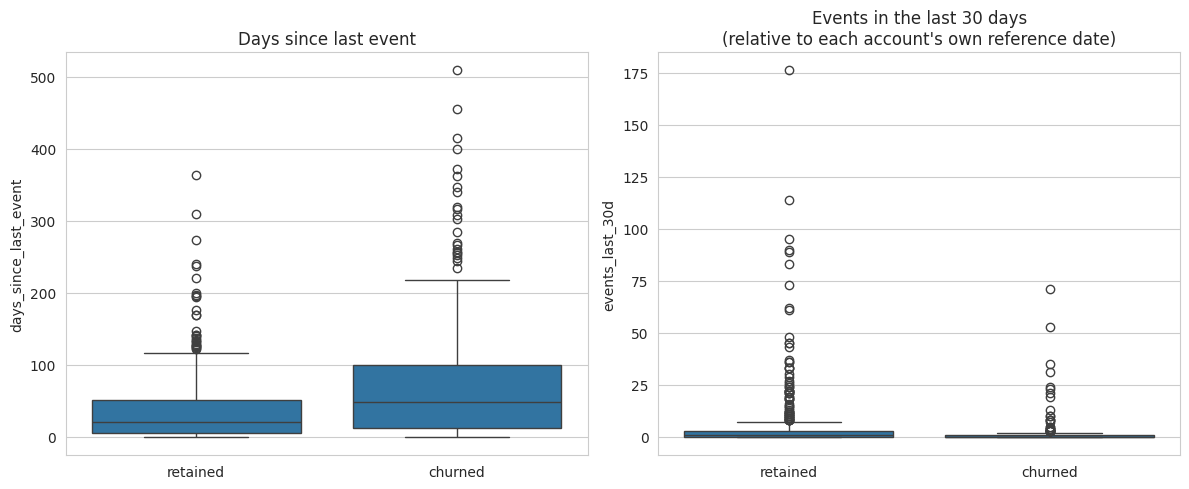

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=combined, x='label', y='days_since_last_event', ax=axes[0], order=['retained', 'churned'])
axes[0].set_title('Days since last event')
axes[0].set_xlabel('')

sns.boxplot(data=combined, x='label', y='events_last_30d', ax=axes[1], order=['retained', 'churned'])
axes[1].set_title('Events in the last 30 days\n(relative to each account\'s own reference date)')
axes[1].set_xlabel('')

plt.tight_layout()

import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/predictor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Top predictor and caveats

**Most important predictor: recency/volume of activity** — `days_since_last_event` (or `events_last_30d`
as the actionable, forward-looking version of the same signal). Churned accounts go quiet well before
they formally cancel; retained accounts stay recently and repeatedly active. This is the candidate finding
that M5 will weigh against M3's cohort result — it's specific and gives Customer Success a concrete trigger:
*flag accounts with fewer than N events in the trailing 30 days.*

**Caveats to carry into `findings/04b_predictors.md`:**
- Scoped to 693 accounts with an unambiguous `active`/`churned` label; `trialing`/`paused`/`past_due`
  accounts (~285) are excluded from this comparison by design.
- `events.account_id`/`user_id` required a type-cast fix (float-string → integer) before any join to
  `accounts` would work at all — flagged here so the same fix is reused in M3 if events end up needed there.
- 198 event-table account_ids are genuine orphans with no matching account; excluded, not otherwise
  investigated.
- Ticket/CSAT findings are directionally consistent with "support engagement retains customers," but the
  effect is smaller and less consistently significant than an earlier, buggier pass suggested — don't
  overstate it as a headline finding.
